In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화
# quiz에서는 scale조정, train_test_split 등을 추가
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

- Red Wine 등급 예측
1. 데이터 겟 확보 및 전처리
    csv -> 결측치 처리 -> 독립변수와 타겟변수 분리 -> 독립변수 스케일조정,
    -> 타겟변수의 원핫인코딩 -> 훈련셋과 테스트셋분리(train_test_split이용 층화추출)
2. 모델 구성(입력11, 출력6 | 출력9) layer층 4
3. 모델 학습 과정 설정
4. 모델학습(callbacks이용)
5. 모델 평가(그래프, 평가, 교차표)
6. 모델저장 & 사용

# 1. 데이터 확보 & 전처리

In [3]:
# 데이터 읽어오기
# fixed acidity : 고정 산도
# volatile acidity : 휘발성 산도
# citric acid : 시트르산
# residual sugar : 잔류 당분
# chlorides : 염화물
# free sulfur dioxide :자유 이산화황
# total sulfur dioxide : 총 이산화황
# density : 밀도
# pH
# sulphates : 황산염
# alcohol
# quality : 0 ~ 10(높을 수록 좋은 품질)
redwine = pd.read_csv('data/winequality-red.csv', sep=';')
redwine['quality'].value_counts()

5    681
6    638
7    199
4     53
8     18
3     10
Name: quality, dtype: int64

In [4]:
# 결측치 확인
print(redwine.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [5]:
# 독립변수(X), 타겟변수(y) 분리
X = redwine.drop('quality', axis=1)
y = redwine['quality']

In [6]:
# 스케일 조정
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# 타겟 원핫 인코딩
y_encoded = to_categorical(y)

In [8]:
# 훈련셋, 테스트셋 분리 (층화 추출)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y_encoded)

In [9]:
# 모델 구성
model = Sequential()
model.add(Input(shape=(11,)))  # 독립변수 11개
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(y_encoded.shape[1], activation='softmax'))

In [10]:
# 모델 학습과정 설정
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [11]:
# 학습
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

hist = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[es],
                    verbose=1)

Epoch 1/200
32/32 [==============================] - 1s 11ms/step - loss: 1.2926 - accuracy: 0.5152 - val_loss: 1.2630 - val_accuracy: 0.5547
Epoch 2/200
32/32 [==============================] - 0s 5ms/step - loss: 1.0103 - accuracy: 0.5973 - val_loss: 1.1071 - val_accuracy: 0.6016
Epoch 3/200
32/32 [==============================] - 0s 4ms/step - loss: 0.9706 - accuracy: 0.5718 - val_loss: 1.1431 - val_accuracy: 0.5391
Epoch 4/200
32/32 [==============================] - 0s 5ms/step - loss: 0.9593 - accuracy: 0.5924 - val_loss: 1.1441 - val_accuracy: 0.5664
Epoch 5/200
32/32 [==============================] - 0s 5ms/step - loss: 0.9208 - accuracy: 0.6012 - val_loss: 1.0743 - val_accuracy: 0.5781
Epoch 6/200
32/32 [==============================] - 0s 5ms/step - loss: 0.8960 - accuracy: 0.6334 - val_loss: 1.0697 - val_accuracy: 0.5820
Epoch 7/200
32/32 [==============================] - 0s 5ms/step - loss: 0.8803 - accuracy: 0.6325 - val_loss: 1.0856 - val_accuracy: 0.5820
Epoch 8/200


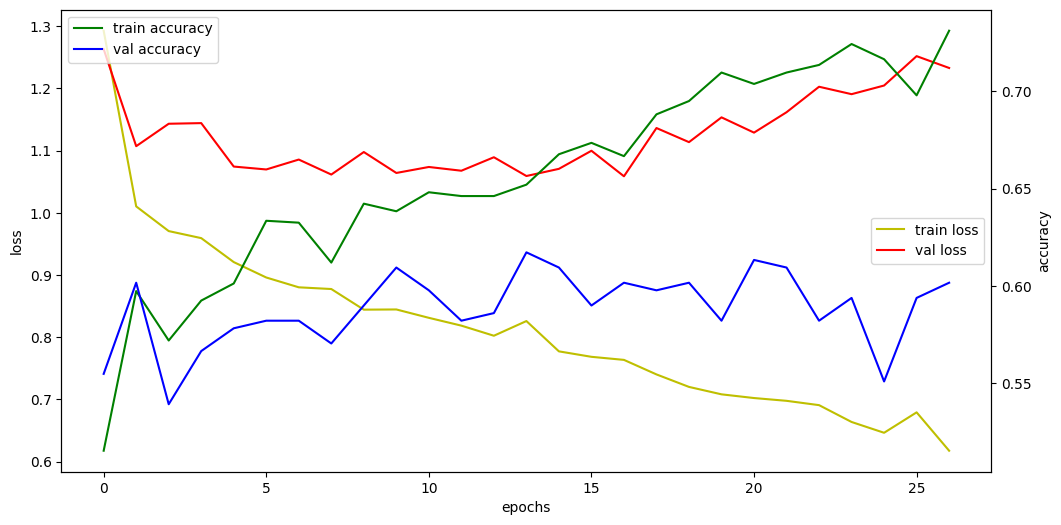

In [12]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()